# Workflows

One of the most powerful but underused features of modern HPC job schedulers is **dependency management**: the ability to declare that job B should not start until job A has finished. SLURM supports this via the `--dependency` flag in `sbatch` ([documentation](https://slurm.schedmd.com/sbatch.html#OPT_dependency)), and Flux has an equivalent mechanism.

The challenge is that wiring up these dependencies manually — writing shell scripts that extract job IDs and feed them to subsequent `sbatch` calls — is tedious and error-prone. Most researchers end up waiting for the entire first batch to finish before submitting the next batch, leaving compute nodes idle.

**`executorlib`'s approach:** Dependencies are expressed naturally in Python by passing a `Future` object as the argument to a subsequent `submit()` call. The executor automatically translates this into a scheduler dependency. You write normal Python; the executor manages the job graph.

**Learning objectives:** After this notebook you will be able to:
- Build dependency chains between Python functions using `Future` objects as arguments
- Visualise the dependency graph of a workflow
- Use `FluxClusterExecutor`'s persistent-queue feature to survive Python session restarts
- Decompose multi-output futures with `split_future()` and `get_item_from_future()`
- Apply the as-completed pattern for exascale many-task workflows


## Dependencies

When the **output of one function is passed as an argument to another**, `executorlib` automatically creates a dependency: the second function will not be submitted to the scheduler until the first has completed and its result is available.

The mechanism is straightforward:

```python
future_a = exe.submit(function_a, arg1)
future_b = exe.submit(function_b, future_a)   # waits for future_a
future_c = exe.submit(function_c, future_b)   # waits for future_b
```

This is equivalent to a SLURM dependency chain:
```bash
JOB_A=$(sbatch job_a.sh | awk '{print $NF}')
JOB_B=$(sbatch --dependency=afterok:$JOB_A job_b.sh | awk '{print $NF}')
JOB_C=$(sbatch --dependency=afterok:$JOB_B job_c.sh)
```

The `executorlib` version is shorter, less error-prone, and naturally expresses the logic of the workflow in Python rather than shell scripting.

The `plot_dependency_graph=True` option renders the dependency graph as a directed acyclic graph (DAG) — useful for verifying that the workflow structure is correct before committing to a long HPC run.


In [1]:
def calc_add(a, b):
    return a + b

In [2]:
from executorlib import SingleNodeExecutor

with SingleNodeExecutor() as exe:
    future = 0
    for i in range(1, 4):
        future = exe.submit(calc_add, i, future)
    print(future.result())

6


None


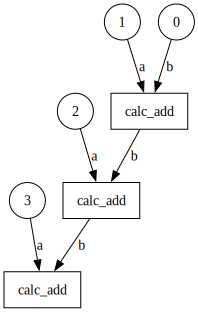

In [3]:
with SingleNodeExecutor(plot_dependency_graph=True) as exe:
    future = 0
    for i in range(1, 4):
        future = exe.submit(calc_add, i, future)
    print(future.result())

## FluxClusterExecutor

The `FluxClusterExecutor` (and its SLURM equivalent `SlurmClusterExecutor`) handle dependencies differently from the `FluxJobExecutor`: they communicate dependencies **directly to the Flux scheduler** rather than managing them in-process.

**What this means in practice:**

When you submit a chain of dependent functions with `FluxClusterExecutor`, each function becomes a Flux job. Flux holds the dependent jobs in its queue and only releases them when their dependencies have been satisfied — even if the Python session is stopped in the meantime. This gives the workflow **session-independence**: you can close your notebook, go home, and Flux will continue executing the job chain overnight. When you reconnect and reload the `Future` objects from the cache, their results are already available.

Compare this with `FluxJobExecutor`, where the Python process must stay alive for the duration of the workflow because dependencies are tracked in-process.


In [4]:
from executorlib import FluxClusterExecutor

with FluxClusterExecutor() as exe:
    future = 0
    for i in range(1, 4):
        future = exe.submit(calc_add, i, future)
    print(future.result())

6


In [5]:
!flux jobs -a

       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO
    ƒ5DEigfq jovyan   executorl+ CD      1      1   1.202s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ5A1vFAP jovyan   executorl+ CD      1      1   1.175s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ56o7oew jovyan   executorl+ CD      1      1   1.186s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u


To demonstrate the session-independence of `FluxClusterExecutor`, the next cells use it **without** a `with` statement. The executor is created, work is submitted, then `exe.shutdown(wait=False)` is called immediately — the Python process does not wait for the jobs to finish. The submitted jobs continue running in the Flux queue. After checking the queue with `flux jobs -a`, a new executor instance is created to retrieve the results from the cache.

First, the cache is cleared to remove results from the previous run:


In [6]:
import shutil
shutil.rmtree("executorlib_cache")

In [7]:
exe = FluxClusterExecutor()
future = 0
for i in range(1, 4):
    future = exe.submit(calc_add, i, future)
exe.shutdown(wait=False, cancel_futures=False)

In [8]:
!flux jobs -a

       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO
    ƒB7dQpUo jovyan   executorl+  D             -        - depends:after-success=382906400768
    ƒBAkHJrs jovyan   executorl+  D             -        - depends:after-success=385037107200
    ƒB4P8Ph1 jovyan   executorl+  R      1      1   0.580s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ5DEigfq jovyan   executorl+ CD      1      1   1.202s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ5A1vFAP jovyan   executorl+ CD      1      1   1.175s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ56o7oew jovyan   executorl+ CD      1      1   1.186s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u


In [9]:
!flux jobs -a

       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO
    ƒBAkHJrs jovyan   executorl+ CD      1      1   1.167s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒB7dQpUo jovyan   executorl+ CD      1      1   1.240s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒB4P8Ph1 jovyan   executorl+ CD      1      1   1.198s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ5DEigfq jovyan   executorl+ CD      1      1   1.202s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ5A1vFAP jovyan   executorl+ CD      1      1   1.175s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ56o7oew jovyan   executorl+ CD      1      1   1.186s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u


In [10]:
exe = FluxClusterExecutor()
future = 0
for i in range(1, 4):
    future = exe.submit(calc_add, i, future)
print(future.result())

6


In [11]:
!flux jobs -a

       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO
    ƒBAkHJrs jovyan   executorl+ CD      1      1   1.167s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒB7dQpUo jovyan   executorl+ CD      1      1   1.240s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒB4P8Ph1 jovyan   executorl+ CD      1      1   1.198s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ5DEigfq jovyan   executorl+ CD      1      1   1.202s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ5A1vFAP jovyan   executorl+ CD      1      1   1.175s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ56o7oew jovyan   executorl+ CD      1      1   1.186s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u


## FluxJobExecutor

The `FluxJobExecutor` handles dependencies **in-process**: when a `Future` is passed as an argument to `submit()`, the executor itself waits for that future to resolve before forwarding the call to the Flux worker. This means the Python session must remain alive for the full duration of the workflow.

**Advantage over `FluxClusterExecutor` for dependency chains:**
Socket communication has much lower overhead than file I/O. For workflows with many short-running tasks linked in a dependency chain, `FluxJobExecutor` can be significantly faster because it does not write an HDF5 file to disk for each function invocation.

The same `calc_add` chain used in the previous sections runs identically with `FluxJobExecutor`:


In [12]:
from executorlib import FluxJobExecutor

with FluxJobExecutor() as exe:
    future = 0
    for i in range(1, 4):
        future = exe.submit(calc_add, i, future)
    print(future.result())

6


In [13]:
!flux jobs -a

       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO
    ƒLYH81DH jovyan   python     CD      1      1   0.161s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒLTre9Td jovyan   python     CD      1      1   0.159s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒLPV8GGf jovyan   python     CD      1      1   0.159s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒBAkHJrs jovyan   executorl+ CD      1      1   1.167s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒB7dQpUo jovyan   executorl+ CD      1      1   1.240s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒB4P8Ph1 jovyan   executorl+ CD      1      1   1.198s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ5DEigfq jovyan   executorl+ CD      1      1   1.202s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ5A1vFAP jovyan   executorl+ CD      1      1   1.175s jupyter-janj-lanl-executorlib-tutorial-9ce2an8u
    ƒ56o7oew jovyan   executorl+ CD      1      1   1.186s jupyter-janj-lanl-exe

## Split future

In many workflows the output of one function cannot be directly fed into the next because the output is a **tuple, list, or dictionary** and only one element is needed downstream.

Naïvely you might call `.result()` to unpack the output:
```python
result = future.result()          # blocks here
a, b, c = result                  # then unpack
next_future = exe.submit(fn, a)   # then submit
```

This defeats the purpose of async execution: the call to `.result()` blocks the main thread until the first function finishes, eliminating any overlap between the first and second functions.

`executorlib` provides two helper functions that solve this **without blocking**:

- `split_future(future, count=N)` — splits a future whose result is a tuple or list of length `N` into `N` individual futures, one per element.
- `get_item_from_future(future, key)` — extracts a single item from a future whose result is a list, tuple, or dictionary, returning it as a new future.

Both helpers return `Future` objects immediately (without blocking) and can be passed directly to subsequent `submit()` calls, preserving the fully non-blocking dependency chain.


In [14]:
from executorlib import split_future, get_item_from_future

In [15]:
def function_with_multiple_outputs(i):
    return "a", "b", i

In [16]:
with SingleNodeExecutor() as exe:
    future = exe.submit(function_with_multiple_outputs, 15)
    f1, f2, f3 = split_future(future=future, n=3)
    print(f1.result(), f2.result(), f3.result())

a b 15


In [17]:
def function_with_a_dict_as_output(i):
    return {"a": 1, "b": 2, "c": i}

In [18]:
with SingleNodeExecutor() as exe:
    future_dict = exe.submit(function_with_a_dict_as_output, 15)
    f1 = get_item_from_future(future=future_dict, key="a")
    f2 = get_item_from_future(future=future_dict, key="b")
    f3 = get_item_from_future(future=future_dict, key="c")
    print(f1.result(), f2.result(), f3.result())

1 2 15


## Exascale many-task pattern

A common pattern in large-scale scientific computing — sometimes called the *eager aggregation* or *as-completed* pattern — is:

1. Submit a large number of independent tasks (hundreds to thousands)
2. As soon as **any subset** of tasks completes, process those results immediately
3. Continue collecting results from remaining tasks as they finish

This avoids the inefficiency of waiting for *all* tasks to finish before post-processing any of them. On an exascale machine with variable task runtimes, the slow tail tasks should not block analysis of the already-finished fast tasks.

`executorlib` supports this pattern by allowing you to filter futures with [`concurrent.futures.as_completed()`](https://docs.python.org/3/library/concurrent.futures.html#concurrent.futures.as_completed) from the standard library, or by checking `future.done()` in a polling loop.

The example below simulates this: most tasks finish quickly, but every fifth task sleeps for five seconds. A secondary aggregation function (`sum_and_elements`) is submitted as soon as a batch of results is available, without waiting for the slow tasks.


In [19]:
from time import sleep

In [20]:
def reply(i):
    if i % 5 == 0:
        sleep(5)
    return i

In [21]:
def sum_and_elements(lst):
    return sum(lst), lst

In [22]:
with FluxJobExecutor(max_workers=2) as exe:
    future_individual_lst = [
        exe.submit(reply, i) for i in range(10)
    ]
    future_group_lst = [
        exe.submit(sum_and_elements, f) for f in exe.batched(future_individual_lst, n=3)
    ]
    print([f.result() for f in future_group_lst])

[(6, [1, 2, 3]), (10, [0, 4, 6]), (20, [5, 7, 8]), (9, [9])]
